
GLOSARIO: TrejoLey_CPS
  • cve_inegi: Municipality INEGI ID
  • state: State name
  • municipality: Municipality name
  • year: Year
  • death_cvm: Count organized crime deaths, CVM
  • death_dummy: CVM dummy, =1 if death_cvm>0, 0 o.w.
  • death_positive: CVM positive counts, =. if death_cvm=0
  • lag_cvm_avg: Average CVM deaths in neighboring municipalities, t-1
  • st_alternation: Alternation at the state level, dummy
  • mun_alternation: Alternation at the municipal level, dummy
  • postauth: Alternation at the national level, dummy
  • subnat_alternation: Subnational alternation index, 0-3
  • mun_cycle: Mayor's years in office
  • gov_cycle: Governor's years in office
  • altgov_count: Interaction=st_alternation*gov_cycle
  • altmun_count: Interaction=mun_alternation*mun_cycle
  • enp_mun: Municipal Effective Number of Parties, CIDAC+Electoral Institutes
  • mpag_10: Prosecutors per 10,000 population, INEGI
  • coca_retail_ch: Change in cocaine price in the previous five years,UN

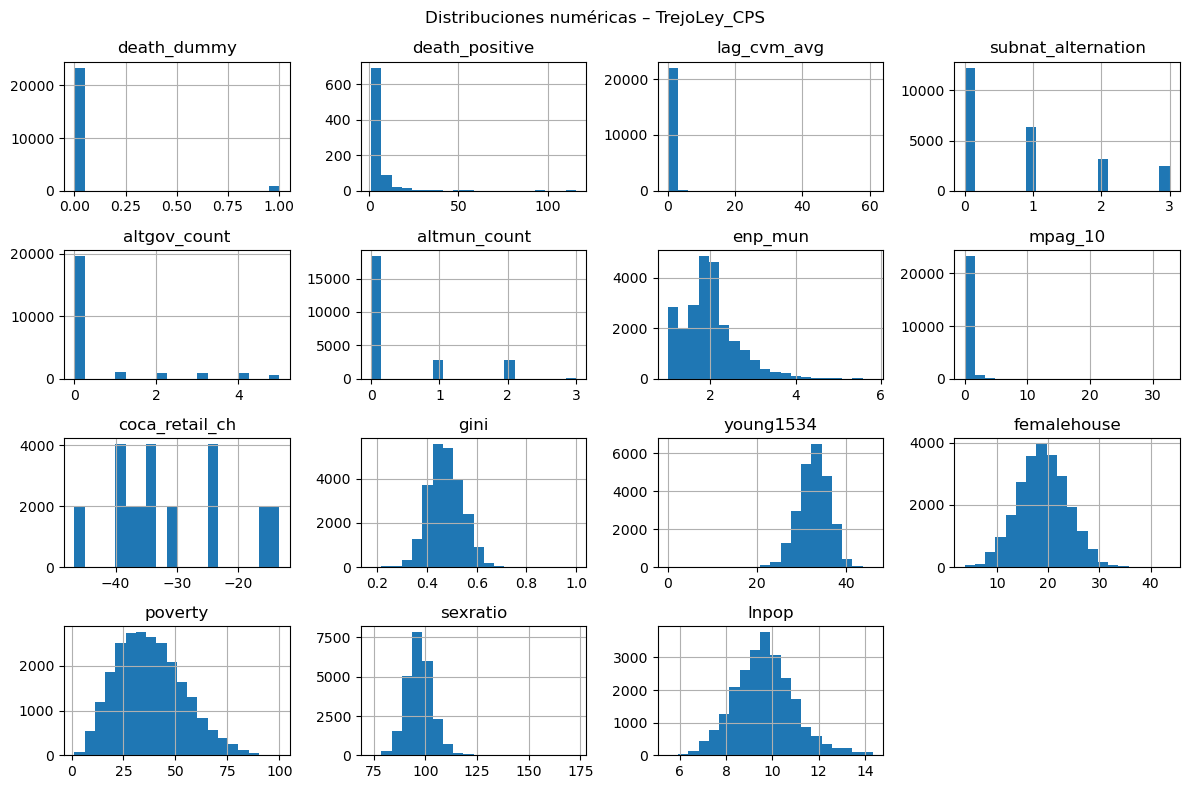

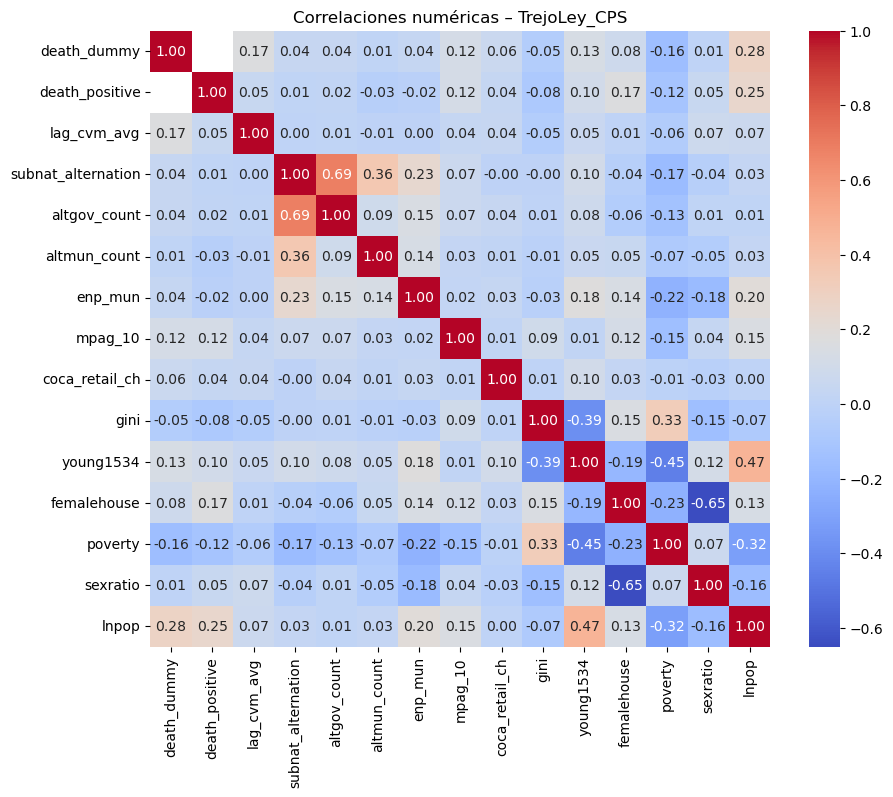

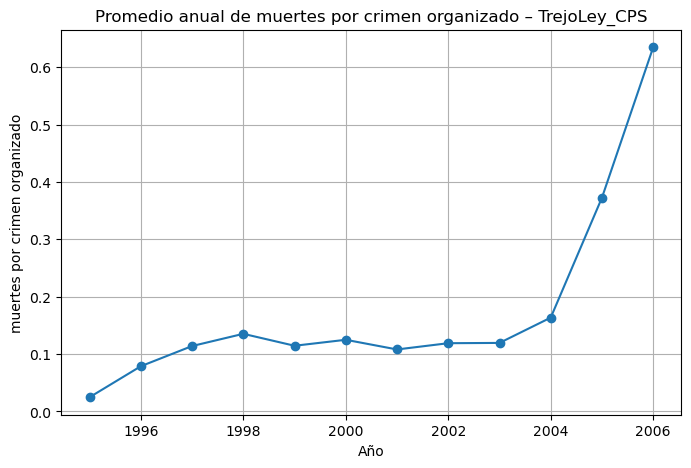

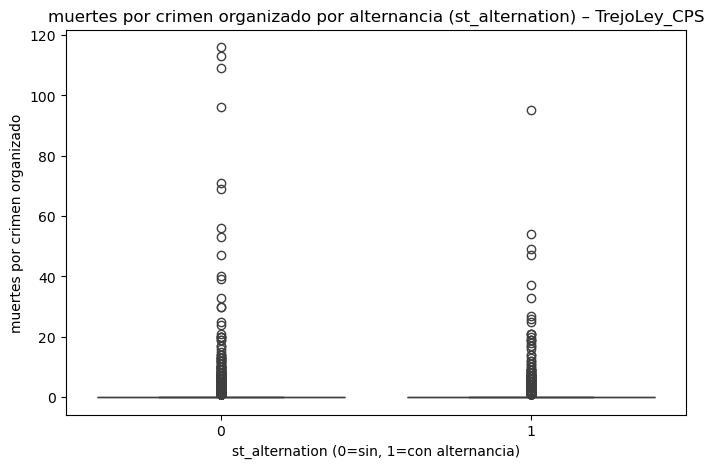


GLOSARIO: HighProfileViolence
  • cve_inegi: Municipal INEGI code
  • state: State name
  • municipality: Municipality name
  • year: year
  • aggr_sum: Total number of attacks
  • aggr_dummy: =1 if positive count of attacks, 0 o.w.
  • cvmr1000: Drug-related murder rate per 1,000 pop (CVM)
  • menfeje1000: Drug-related murder rate per 1,000 pop (Govt)
  • juxt1: PAN, PAN, PAN
  • juxt2: PAN, PAN, PRI/PVEM
  • juxt3: PAN, PAN, PRD/PT/CONV
  • juxt4: PAN, PRI, PAN
  • juxt5: PAN, PRI, PRI/PVEM
  • juxt6: PAN, PRI, PRD/PT/CONV
  • juxt7: PAN, PRD, PAN
  • juxt8: PAN, PRD, PRI/PVEM
  • juxt9: PAN, PRD, PRD/PT/CONV
  • juxtaposition: Juxtaposition index
  • juxt_cvm: Juxtaposition*CVM
  • elect_local: Election year at the local level (governor and/or mayor)
  • elec_cvm: elect_local*CVM
  • elect_fed: elect_fed
  • lag_neightotal: Attacks among neighbors, t-1
  • perc_tax: % municipal income derived from tax collection
  • mpoff1000: Public prosecutor offices per 1,000 pop.
  • alternanci

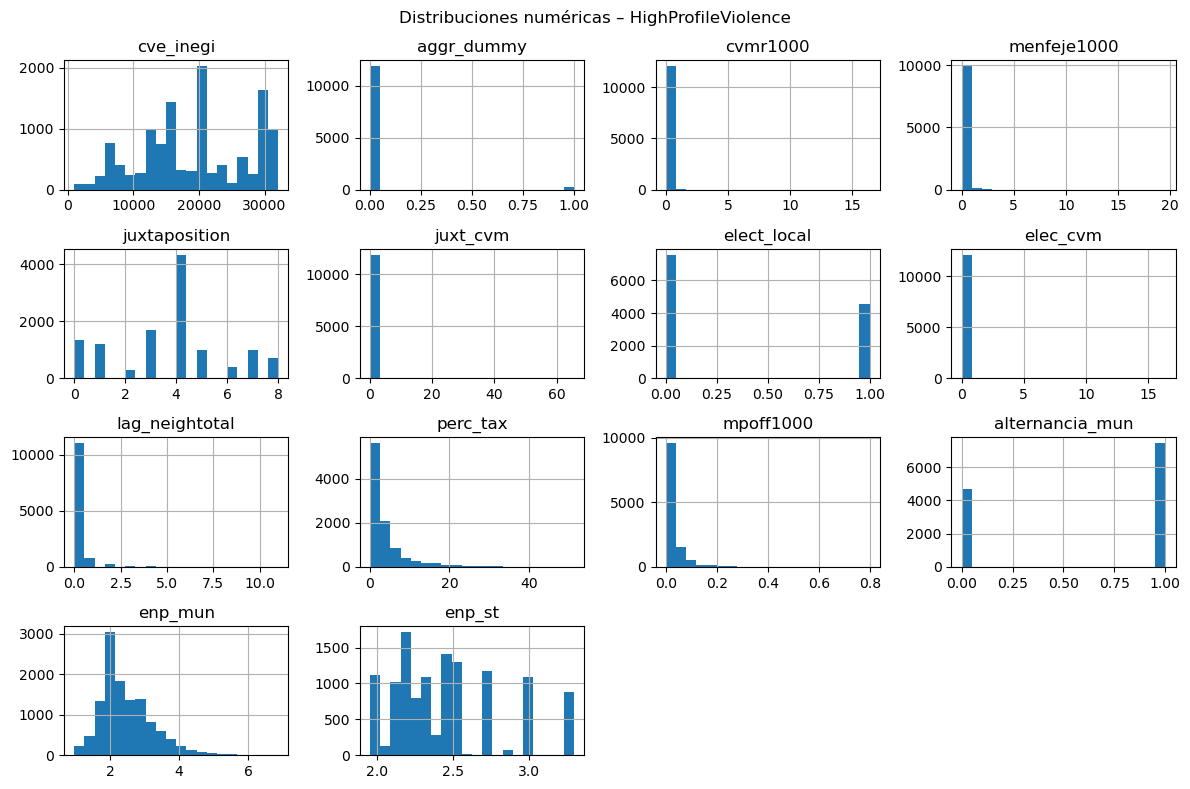

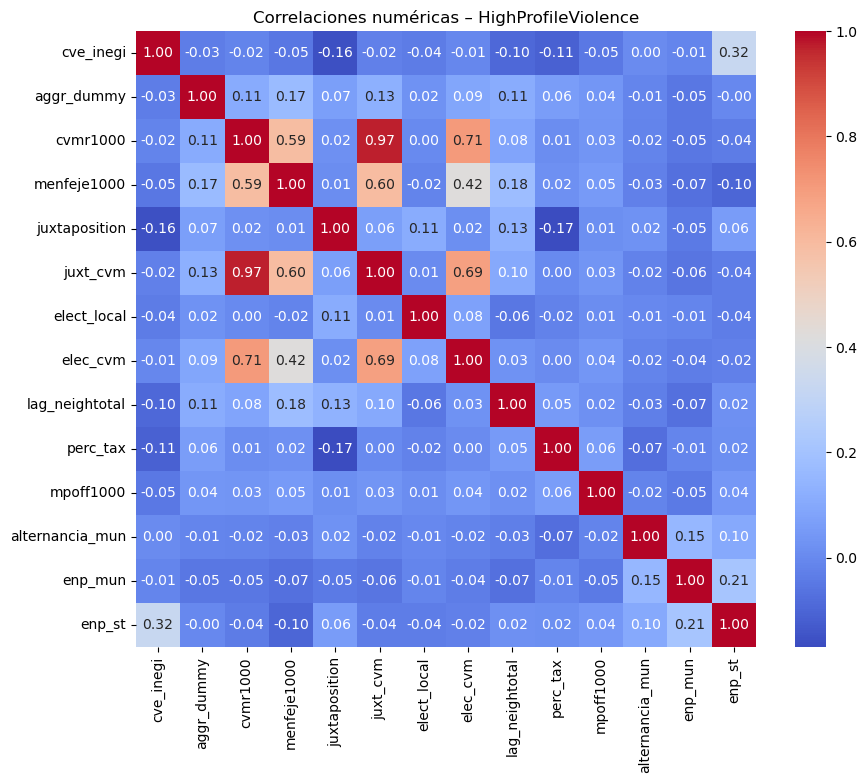

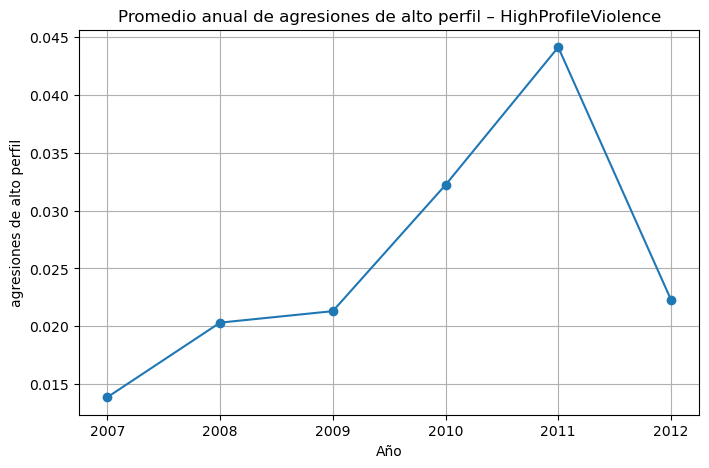

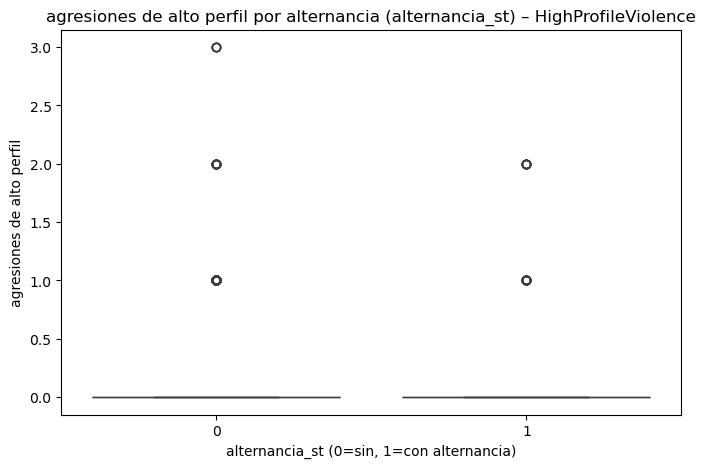


GLOSARIO: ViolenciaPolitica
  • id: Identificador del evento (estado abreviado + fecha)
  • id_evento: Identificador numérico del evento
  • id_victima: Identificador numérico de la víctima
  • tipo_vic: Tipo de víctima (Autoridad/Partido/Instalación)
  • nom_vic: Nombre de la víctima o institución atacada
  • genero_vic: Género de la víctima
  • partido1: Partido de la víctima (1)
  • partido2: Partido de la víctima (2)
  • partido3: Partido de la víctima (3)
  • partido4: Partido de la víctima (4)
  • coalicion: Coalición a la que pertenece la víctima
  • puesto1: Título del primer puesto que ocupa la víctima
  • puesto2: Título del segundo puesto que ocupa la víctima
  • puesto3: Título del tercer puesto que ocupa la víctima
  • cat_puesto1: Categoría del primer puesto
  • cat_puesto2: Categoría del segundo puesto
  • cat_puesto3: Categoría del tercer puesto
  • nivel_gob: Nivel de gobierno de la víctima
  • area_gob: Área de gobierno de la víctima
  • tipo_evento: Tipo de evento o

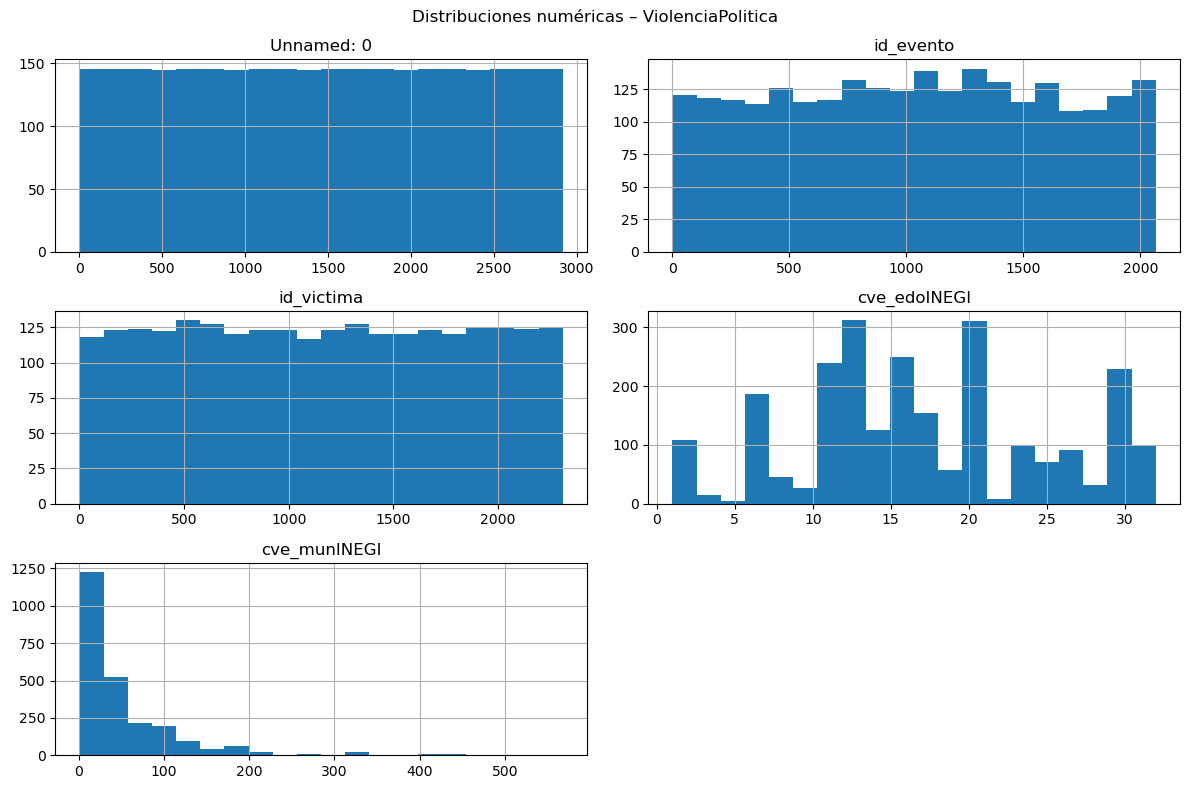

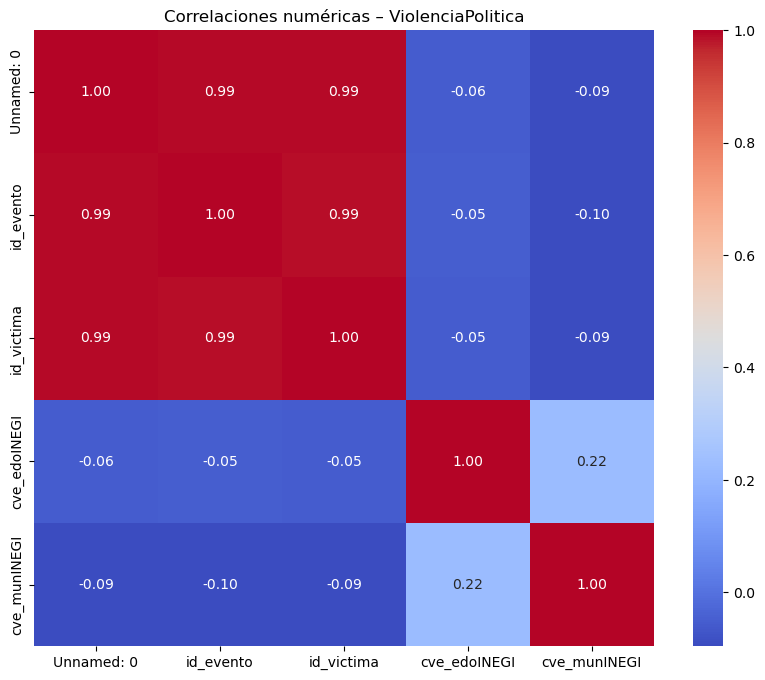


Análisis EDA completado para las tres bases.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.io.stata import StataReader

# 1) Rutas a los archivos
rutas = {
    "TrejoLey_CPS":     r"C:\Users\Rog Strix\OneDrive\Escritorio\VIOLENCIA POLÍTICA\TrejoLey_CPS_Dataset_Stata13.dta",
    "HighProfileViolence": r"C:\Users\Rog Strix\OneDrive\Escritorio\VIOLENCIA POLÍTICA\Dataset_HighProfileCriminalViolence.dta",
    "ViolenciaPolitica":    r"C:\Users\Rog Strix\OneDrive\Escritorio\VIOLENCIA POLÍTICA\political_violence.csv"
}

# 2) Glosario para la base CSV 'ViolenciaPolitica'
diccionario_vp = {
    'id': 'Identificador del evento (estado abreviado + fecha)',
    'id_evento': 'Identificador numérico del evento',
    'id_victima': 'Identificador numérico de la víctima',
    'tipo_vic': 'Tipo de víctima (Autoridad/Partido/Instalación)',
    'nom_vic': 'Nombre de la víctima o institución atacada',
    'genero_vic': 'Género de la víctima',
    'partido1': 'Partido de la víctima (1)',
    'partido2': 'Partido de la víctima (2)',
    'partido3': 'Partido de la víctima (3)',
    'partido4': 'Partido de la víctima (4)',
    'coalicion': 'Coalición a la que pertenece la víctima',
    'puesto1': 'Título del primer puesto que ocupa la víctima',
    'puesto2': 'Título del segundo puesto que ocupa la víctima',
    'puesto3': 'Título del tercer puesto que ocupa la víctima',
    'cat_puesto1': 'Categoría del primer puesto',
    'cat_puesto2': 'Categoría del segundo puesto',
    'cat_puesto3': 'Categoría del tercer puesto',
    'nivel_gob': 'Nivel de gobierno de la víctima',
    'area_gob': 'Área de gobierno de la víctima',
    'tipo_evento': 'Tipo de evento o agresión',
    'agresor': 'Cartel o pandilla agresor',
    'fecha': 'Fecha del evento (AAAA-MM-DD)',
    'estado': 'Entidad federativa del evento',
    'municipio': 'Municipio del evento',
    'cve_edoINEGI': 'Clave INEGI de la entidad de ocurrencia',
    'cve_munINEGI': 'Clave INEGI del municipio de ocurrencia'
}

# 3) Función para imprimir glosario de variables

def imprimir_glosario(nombre, etiquetas):
    print(f"\n{'='*60}\nGLOSARIO: {nombre}\n{'='*60}")
    for var, desc in etiquetas.items():
        print(f"  • {var}: {desc}")

# 4) Función de EDA general

def eda_general(df, nombre, var_tiempo=None, var_alternancia=None, etiqueta_tiempo=None):
    print(f"\n{'='*60}\nEDA: {nombre}\n{'='*60}")
    # Visión general
    print(f"- Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
    print(f"- Tipos de datos:\n{df.dtypes}\n")
    print(f"- Primeras 5 filas:\n{df.head()}\n")

    # Estadísticas descriptivas
    print("Resumen estadístico:\n", df.describe(include='all'), "\n")

    # Valores faltantes
    faltantes = df.isnull().sum().sort_values(ascending=False)
    print("Valores faltantes por variable:\n", faltantes[faltantes > 0], "\n")

    # Histogramas de variables numéricas
    num_vars = df.select_dtypes(include=['int64','float64','int32','float32']).columns
    df[num_vars].hist(bins=20, figsize=(12, 8))
    plt.suptitle(f"Distribuciones numéricas – {nombre}")
    plt.tight_layout()
    plt.show()

    # Mapa de calor de correlaciones
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[num_vars].corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Correlaciones numéricas – {nombre}")
    plt.show()

    # Serie temporal de var_tiempo
    if var_tiempo and var_tiempo in df.columns:
        plt.figure(figsize=(8, 5))
        df.groupby('year')[var_tiempo].mean().plot(marker='o')
        plt.title(f"Promedio anual de {etiqueta_tiempo} – {nombre}")
        plt.xlabel("Año")
        plt.ylabel(etiqueta_tiempo)
        plt.grid(True)
        plt.show()

    # Boxplot según alternancia
    if var_alternancia and var_alternancia in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=var_alternancia, y=var_tiempo, data=df)
        plt.title(f"{etiqueta_tiempo} por alternancia ({var_alternancia}) – {nombre}")
        plt.xlabel(f"{var_alternancia} (0=sin, 1=con alternancia)")
        plt.ylabel(etiqueta_tiempo)
        plt.show()

# 5) Ejecutar glosario y EDA para las tres bases
for nombre, ruta in rutas.items():
    if nombre in ['TrejoLey_CPS', 'HighProfileViolence']:
        lector = StataReader(ruta)
        df = lector.read()
        etiquetas = lector.variable_labels()
        # Glosario Stata
        imprimir_glosario(nombre, etiquetas)
        # EDA Stata
        if nombre == 'TrejoLey_CPS':
            eda_general(df, nombre, var_tiempo='death_cvm', var_alternancia='st_alternation', etiqueta_tiempo='muertes por crimen organizado')
        else:
            eda_general(df, nombre, var_tiempo='aggr_sum', var_alternancia='alternancia_st', etiqueta_tiempo='agresiones de alto perfil')
    else:
        # Cargar CSV
        df = pd.read_csv(ruta, parse_dates=['fecha'])
        # Glosario CSV
        imprimir_glosario(nombre, diccionario_vp)
        # EDA CSV (sin var_tiempo específico)
        eda_general(df, nombre)

print("\nAnálisis EDA completado para las tres bases.")


Glosario de variables – ViolenciaPolítica
 • id: Identificador compuesto: estado(3 letras)+fecha
 • id_evento: ID numérico del evento
 • id_victima: ID numérico de la víctima
 • tipo_vic: Tipo de víctima: Autoridad/Partido/Instalación
 • nom_vic: Nombre de la víctima o institución
 • genero_vic: Género de la víctima
 • partido1–4: Partido(s) de la víctima (se desdobla si coalición)
 • coalicion: Coalición de la víctima
 • puesto1–3: Puesto(s) político(s) de la víctima
 • cat_puesto1–3: Categoría de puesto (Familiar, Candidato, etc.)
 • nivel_gob: Nivel de gobierno (Federal, Estatal, Municipal)
 • area_gob: Área de gobierno (Ejecutivo, Legislativo, etc.)
 • tipo_evento: Tipo de agresión (Asesinato, Secuestro, ...)
 • agresor: Cartel o grupo agresor
 • Obs_agresor: Observaciones sobre el agresor
 • fecha: Fecha del evento (AAAA-MM-DD)
 • estado: Entidad donde ocurrió
 • municipio: Municipio donde ocurrió
 • cve_edoINEGI: Clave INEGI de la entidad
 • cve_munINEGI: Clave INEGI del municipi

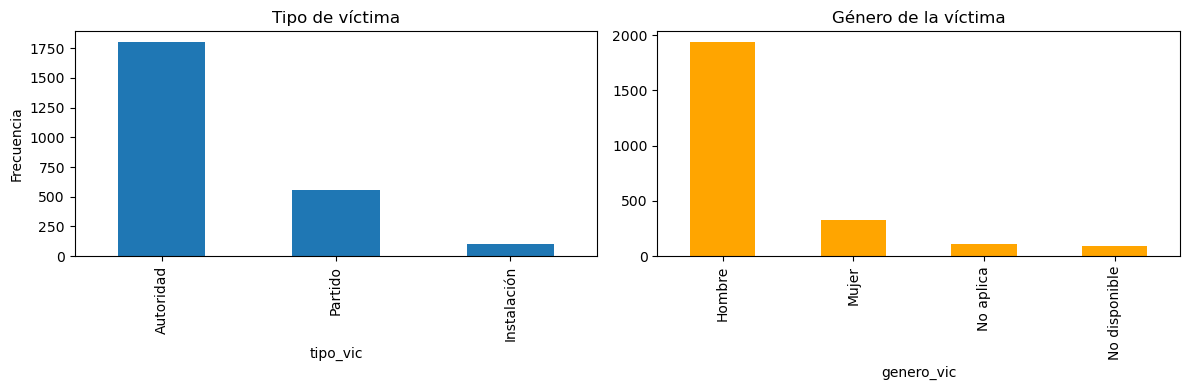

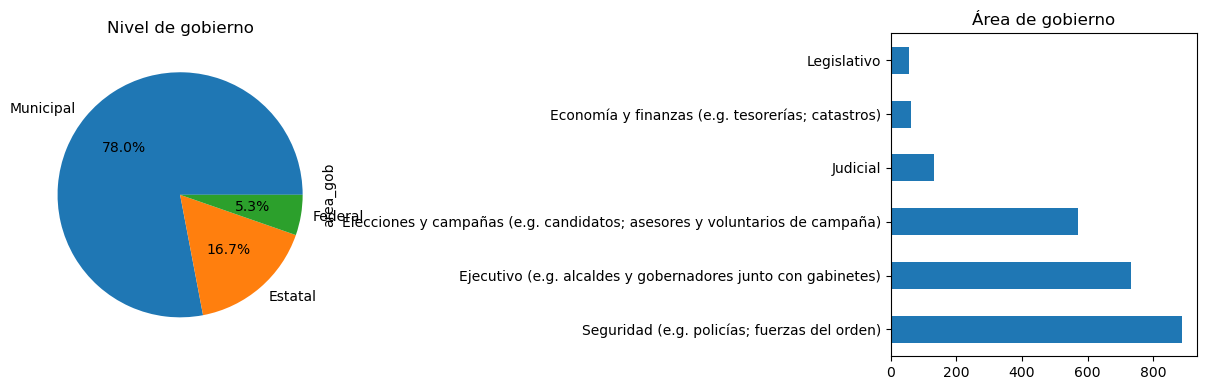

C:\Users\Rog Strix\AppData\Local\Temp\ipykernel_3112\1472817482.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df.set_index('fecha').resample('M').size()


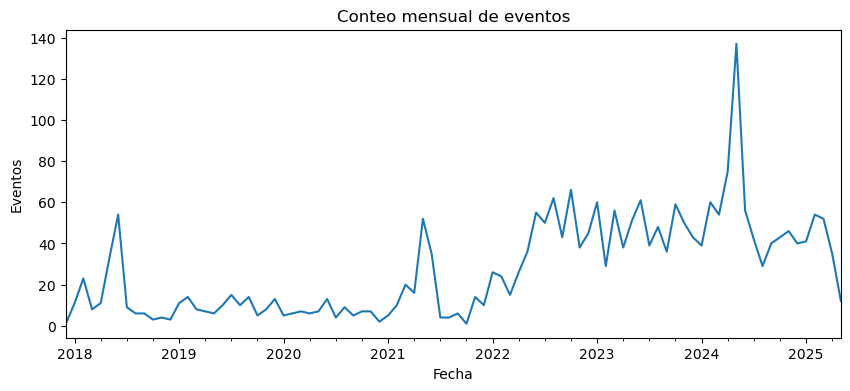

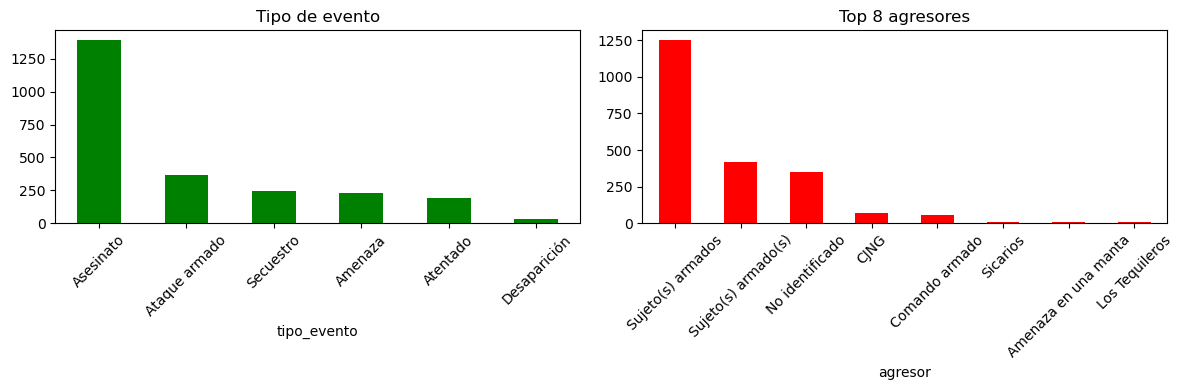

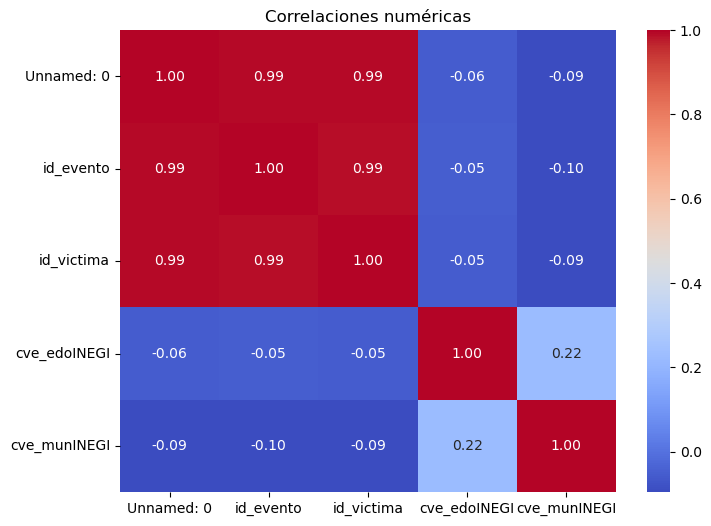

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Carga de datos y glosario
ruta = r"C:\Users\Rog Strix\OneDrive\Escritorio\VIOLENCIA POLÍTICA\political_violence.csv"
df = pd.read_csv(ruta, parse_dates=['fecha'])

# 2) Glosario impreso
glosario = {
    'id': 'Identificador compuesto: estado(3 letras)+fecha',
    'id_evento': 'ID numérico del evento',
    'id_victima': 'ID numérico de la víctima',
    'tipo_vic': 'Tipo de víctima: Autoridad/Partido/Instalación',
    'nom_vic': 'Nombre de la víctima o institución',
    'genero_vic': 'Género de la víctima',
    'partido1–4': 'Partido(s) de la víctima (se desdobla si coalición)',
    'coalicion': 'Coalición de la víctima',
    'puesto1–3': 'Puesto(s) político(s) de la víctima',
    'cat_puesto1–3': 'Categoría de puesto (Familiar, Candidato, etc.)',
    'nivel_gob': 'Nivel de gobierno (Federal, Estatal, Municipal)',
    'area_gob': 'Área de gobierno (Ejecutivo, Legislativo, etc.)',
    'tipo_evento': 'Tipo de agresión (Asesinato, Secuestro, ...)',
    'agresor': 'Cartel o grupo agresor',
    'Obs_agresor': 'Observaciones sobre el agresor',
    'fecha': 'Fecha del evento (AAAA-MM-DD)',
    'estado': 'Entidad donde ocurrió',
    'municipio': 'Municipio donde ocurrió',
    'cve_edoINEGI': 'Clave INEGI de la entidad',
    'cve_munINEGI': 'Clave INEGI del municipio'
}
print("Glosario de variables – ViolenciaPolítica")
for var, desc in glosario.items():
    print(f" • {var}: {desc}")

# 3) Visión general
print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\nTipos de datos:")
print(df.dtypes)
print("\nPrimeras 5 filas:")
print(df.head(), "\n")

# 4) Estadísticas descriptivas y valores faltantes
print("Resumen estadístico de variables numéricas:")
print(df.select_dtypes(include='number').describe(), "\n")
print("Valores faltantes por variable:")
print(df.isnull().sum().loc[lambda x: x>0], "\n")

# 5) Distribución de tipos de víctima y género
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df['tipo_vic'].value_counts().plot.bar()
plt.title("Tipo de víctima")
plt.ylabel("Frecuencia")
plt.subplot(1,2,2)
df['genero_vic'].value_counts().plot.bar(color='orange')
plt.title("Género de la víctima")
plt.tight_layout()
plt.show()

# 6) Eventos por nivel y área de gobierno
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df['nivel_gob'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Nivel de gobierno")
plt.ylabel("")
plt.subplot(1,2,2)
df['area_gob'].value_counts().plot.barh()
plt.title("Área de gobierno")
plt.tight_layout()
plt.show()

# 7) Serie temporal de eventos
ts = df.set_index('fecha').resample('M').size()
plt.figure(figsize=(10,4))
ts.plot()
plt.title("Conteo mensual de eventos")
plt.xlabel("Fecha")
plt.ylabel("Eventos")
plt.show()

# 8) Tipos de agresión y agresores
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df['tipo_evento'].value_counts().plot.bar(color='green')
plt.title("Tipo de evento")
plt.xticks(rotation=45)
plt.subplot(1,2,2)
top_agresores = df['agresor'].value_counts().nlargest(8)
top_agresores.plot.bar(color='red')
plt.title("Top 8 agresores")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9) Correlaciones numéricas
num = df.select_dtypes(include='number')
if num.shape[1] > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlaciones numéricas")
    plt.show()